# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [27]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [28]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
- El dataset no tiene valores ausentes (nulos) en ninguna de sus 9 columnas.
- No se encontraron registros duplicados.
    * La columna date es de tipo object (texto) y debería de ser de tipo datetime, ya que representa fechas.
    * El resto de las columnas tiene un tipo de dato correcto:
        user_id, landing, region, dispositivo, traffic_source, user_type: texto (string/object), correcto ya que son variables categóricas/identificadores.
    * converted: entero (int64), correcto ya que es una variable binaria (0/1).
    * gasto: decimal (float64), correcto ya que representa un monto monetario.
El dataset contiene 40,000 registros y 9 columnas en total.

In [5]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1].describe()

,converted,gasto
count,5706.0,5706.000000
mean,1.0,65.373668
std,0.0,30.896545
min,1.0,12.120000
25%,1.0,42.950000
50%,1.0,59.860000
75%,1.0,80.370000
max,1.0,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")

columnas_categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Conteo de categorías:

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ 
**Hallazgos:**

- La columna `landing` tiene únicamente las dos categorías esperadas del experimento: **A** (19,982 registros) y **B** (20,018 registros), con una distribución relativamente balanceada (~50/50).
- No hay valores negativos, mal escritos o inesperados en ninguna columna categórica.
- Todas las columnas tienen valores esperados:
  - `region`: 5 categorías (Norte, Centro, Sur, Occidente, Oriente), con Norte como la más frecuente.
  - `dispositivo`: 2 categorías (Mobile, Desktop), con predominancia de Mobile.
  - `traffic_source`: 4 categorías (Organic, Ads, Email, Referral), con Organic como la más común.
  - `user_type`: 2 categorías (Nuevo, Recurrente), con más usuarios Nuevos que Recurrentes.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [32]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
print(len(gasto_A), len(gasto_B))
print ()  # Salto de línea

# Obtenemos los valores de gasto promedio
print(gasto_A.mean())
print(gasto_B.mean())
print()  # Salto de línea

# Prueba de varianzas iguales
l_stat, p_levene = levene(gasto_A, gasto_B)
print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_levene}")

2512 3194

61.0865724522293
68.74536005009392

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08


### Prueba Welch

**Hipótesis:**
Se compara el gasto promedio de los usuarios convertidos entre la página A y la página B.
Se usa un nivel de significancia α = 0.05.
- **Hipótesis nula (H₀):**  No existe diferencia estadísticamente significativa en la distribución del gasto entre los usuarios de la página A y la página B.
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa en la distribución del gasto entre los usuarios de la página A y la página B.

In [13]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p (3.63× 10⁻²¹) es mucho menor que α = 0.05, se rechaza la hipótesis nula (H₀) de Levene. Las varianzas son distintas entre A y B. Existe evidencia estadísticamente significativa de que el gasto promedio difiere entre los usuarios convertidos de la página A y la página B.

**Interpretación de negocio:**  
Los usuarios que convirtieron a través de la página B gastan, en promedio, más que los que convirtieron con la página A. El estadístico negativo (-9.48) confirma que el grupo A tiene un gasto promedio menor que el grupo B. Esto indica que la página B no solo genera conversiones (como se vio en el paso anterior), sino que además los clientes que llegan por esa vía tienden a gastar más dinero. En conjunto, esto sugiere que la página B aporta mayor valor económico al negocio.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual entre la página A y la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [14]:
# Número de usuarios convertidos por página
convertidos_por_pagina = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_por_pagina = df.groupby('landing').size()

print("Usuarios convertidos por página:\n", convertidos_por_pagina)
print("\nTotal de usuarios por página:\n", total_por_pagina)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
dtype: int64


In [15]:
# Aplicar prueba
conversiones = [convertidos_por_pagina['A'], convertidos_por_pagina['B']]
n = [total_por_pagina['A'], total_por_pagina['B']]

z_stat, p_value = proportions_ztest(conversiones, n)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

tasa_A = convertidos_por_pagina['A'] / total_por_pagina['A']
tasa_B = convertidos_por_pagina['B'] / total_por_pagina['B']

print(f"Tasa de Conversión A: {tasa_A}") 
print(f"Tasa de Conversión B: {tasa_B}") 

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Tasa de Conversión A: 0.12571314182764487
Tasa de Conversión B: 0.15955639924068338


### 📝 Conclusión e interpretación

**Decisión:**  
Como el valor p (3.76 × 10⁻²²) es muchísimo menor que α = 0.05, se rechaza la hipótesis nula (H₀). Existe evidencia estadísticamente significativa de que la tasa de conversión difiere entre la página A y la página B.

**Interpretación de negocio:**  
La página B tiene una tasa de conversión de 15.95%, frente al 12.57% de la página A — una diferencia de casi 3.4 puntos porcentuales, y el estadístico negativo confirma que A convierte menos que B. Combinado con el hallazgo anterior (los usuarios de B también gastan más en promedio).

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión (son independientes).
- **Hipótesis alternativa (H₁):** Existe una asociación entre la fuente de tráfico y la conversión (no son independientes).

In [16]:
# Creamos la tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [17]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Grados de libertad: {dof}")

print() # Salto de línea

tasas = df.groupby('traffic_source')['converted'].mean().sort_values(ascending=False)
print(tasas)

Estadístico Chi2: 8.6621
Valor p: 0.0341
Grados de libertad: 3

traffic_source
Email       0.149927
Ads         0.147382
Referral    0.138812
Organic     0.137877
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
El valor p (0.0341) es menor que α = 0.05, así que se rechaza la hipótesis nula (H₀). Existe evidencia estadísticamente significativa de una asociación entre la fuente de tráfico y la conversión, aunque el resultado es mucho menos contundente que en las pruebas anteriores (p ≈ 0.03 frente a p ≈ 10⁻²¹).

**Interpretación de negocio:**  
En cantidades absolutas, Organic es la fuente que más conversiones genera (2,480), simplemente porque es también la que más tráfico trae (17,987 usuarios). Sin embargo, al ver las tasas de conversión, Email (14.99%) y Ads (14.74%) convierten proporcionalmente mejor que Organic (13.79%) y Referral (13.88%). Esto sugiere que, aunque Organic aporta el mayor volumen de conversiones, los canales de Email y Ads son relativamente más eficientes por visitante.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** "La tasa de conversión es igual entre usuarios nuevos y recurrentes."
- **Hipótesis alternativa (H₁):** "La tasa de conversión es diferente entre usuarios nuevos y recurrentes."

In [43]:
# Tabla de contingencia
tabla = pd.crosstab(df['user_type'], df['converted'])
print(tabla)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [46]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

Estadístico Chi2: 0.5135
Valor p: 0.473634
Grados de libertad: 1


### 📝 Conclusión e interpretación

**Decisión:**  
El valor p (0.4644) es mucho mayor que α = 0.05, así que no se rechaza la hipótesis nula (H₀). No hay evidencia estadísticamente significativa de que la tasa de conversión difiera entre usuarios nuevos y recurrentes.

**Interpretación de negocio:**  
A diferencia de los pasos anteriores (donde sí encontramos diferencias significativas por página, por fuente de tráfico), aquí el resultado es distinto: el tipo de usuario (nuevo vs. recurrente) no parece influir en la probabilidad de conversión — las tasas son prácticamente idénticas (14.36% vs 14.09%). Esto tiene sentido con la aclaración que se dio al inicio: ser "recurrente" solo indica que visitó antes, no que ya haya comprado, así que no necesariamente trae consigo mayor familiaridad o confianza que impulse la conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

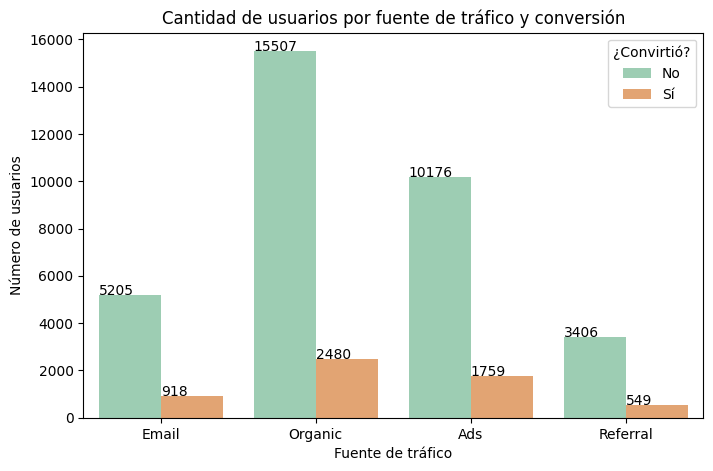

In [21]:
# Cantidad absoluta de usuarios que convirtieron y no convirtieron por fuente de tráfico
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ['#95D5B2', '#F4A261'])

# Agregar valores
for bar in ax.patches:           # Recorrer todas las barras del gráfico
    height = bar.get_height()    # Obtener altura de la barra (conteo de usuarios)
    ax.text(x=bar.get_x(),         # Establecer coordenada X del texto (inicio de la barra)
            y=height,              # Establecer coordenada Y del texto (parte superior de la barra)
            s=height)          # Establecer coordenada X del texto (inicio de la barra)
            
            
plt.title('Cantidad de usuarios por fuente de tráfico y conversión')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Número de usuarios')
plt.legend(title='¿Convirtió?', labels=['No', 'Sí'])
plt.show()

✍️ **Comentario**: 
En términos absolutos, Organic es la fuente que genera más conversiones (2,480), seguida de Ads (1,759). Esto se debe principalmente a que también son las fuentes con mayor volumen total de tráfico, no necesariamente a que sean más efectivas por visitante.

landing
A    0.125713
B    0.159556
Name: converted, dtype: float64


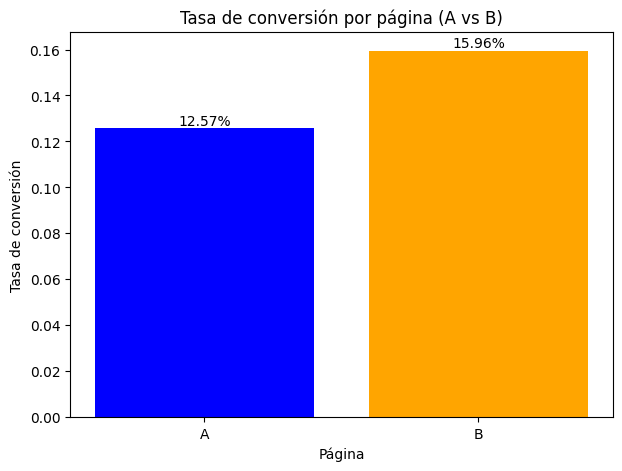

In [38]:
# Calcular la tasa de conversion por pagina
tasa_conversion = df.groupby('landing')['converted'].mean()
print(tasa_conversion)

# Graficar
plt.figure(figsize=(7,5))
plt.bar(tasa_conversion.index, tasa_conversion.values, color=['blue', 'orange'])
plt.title('Tasa de conversión por página (A vs B)')
plt.xlabel('Página')
plt.ylabel('Tasa de conversión')

# Agregar el valor arriba de cada barra
for i in range(len(tasa_conversion)):
    plt.text(i, tasa_conversion.values[i], 
             f'{tasa_conversion.values[i]:.2%}', 
             ha='center', 
             va='bottom')

plt.show()

✍️ **Comentario**:
Se observa que la página B tiene una tasa de conversión de (15.96%), superior a la página A (12.57%). La diferencia de 3.4 puntos es consistente con la prueba Z realizada anteriormente, confirmando que la prueba B convierte visitantes en clientes de forma más efectiva.

[61.0865724522293, 68.74536005009392]


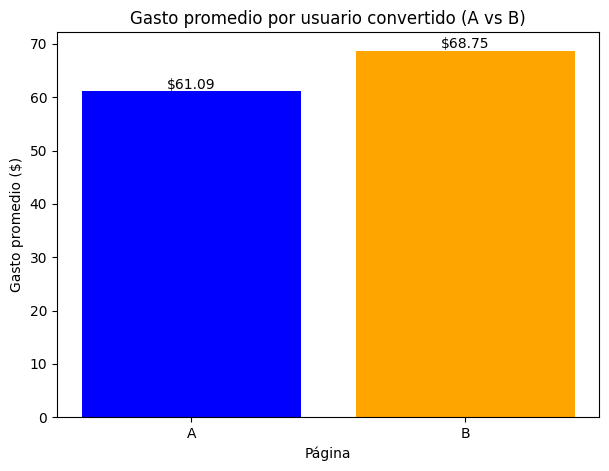

In [40]:
# Calcular el gasto promedio de los usuarios convertidos en cada pagina
gasto_promedio_A = gasto_A.mean()
gasto_promedio_B = gasto_B.mean()

paginas = ['A', 'B']
gastos = [gasto_promedio_A, gasto_promedio_B]

print(gastos)

# Graficar
plt.figure(figsize=(7,5))
plt.bar(paginas, gastos, color=['blue', 'orange'])
plt.title('Gasto promedio por usuario convertido (A vs B)')
plt.xlabel('Página')
plt.ylabel('Gasto promedio ($)')

# Agregar el valor arriba de cada barra
for i in range(len(paginas)):
    plt.text(i, gastos[i], f'${gastos[i]:.2f}', ha='center', va='bottom')

plt.show()

✍️ **Comentario**:
Se observa que los usuarios que convirtieron en la página B gastan en promedio ($68.75), mientras que en la página A gastan ($61.09), una diferencia de $7.66. Respaldando lo visto en el paso 2, confirmando que la página B no solo convierte más, sino que también genera mayor valor económico.

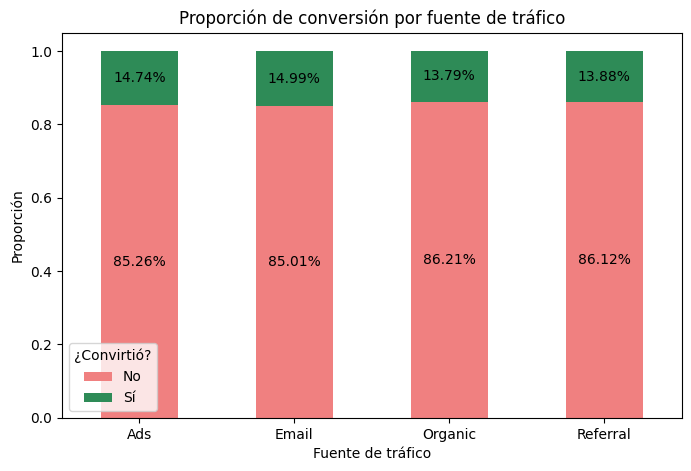

In [22]:
# Proporción de usuarios que convirtieron y no convirtieron por fuente de tráfico
proporciones = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')

ax = proporciones.plot(kind='bar', stacked=True, figsize=(8,5), color=['lightcoral', 'seagreen'])

# Agregar valores
for bar in ax.patches:           # Recorrer todas las barras del gráfico
    height = bar.get_height()    # Obtener altura de la barra (conteo de usuarios)
    x_centro = bar.get_x() + bar.get_width() /2
    y_centro = bar.get_y() + height/ 2
    ax.text(x=x_centro,         # Establecer coordenada X del texto (inicio de la barra)
            y=y_centro,              # Establecer coordenada Y del texto (parte superior de la barra)
            s=f'{height:.2%}',              # Valor númerico a mostrar
            ha='center',
            va='center')
    
plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')
plt.legend(title='¿Convirtió?', labels=['No', 'Sí'])
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Al ver la proporción de conversión por fuente, Email (14.99%) y Ads (14.74%) muestran una tasa de conversión relativa ligeramente más alta que Organic (13.79%) y Referral (13.88%). Esto confirma lo encontrado con la prueba Chi-cuadrado: aunque la diferencia es estadísticamente significativa (p = 0.034), es una diferencia modesta — ninguna fuente domina claramente en efectividad relativa, aunque Email y Ads destacan levemente por encima de Organic y Referral.

### Relación entre el tipo de usuario y la conversión

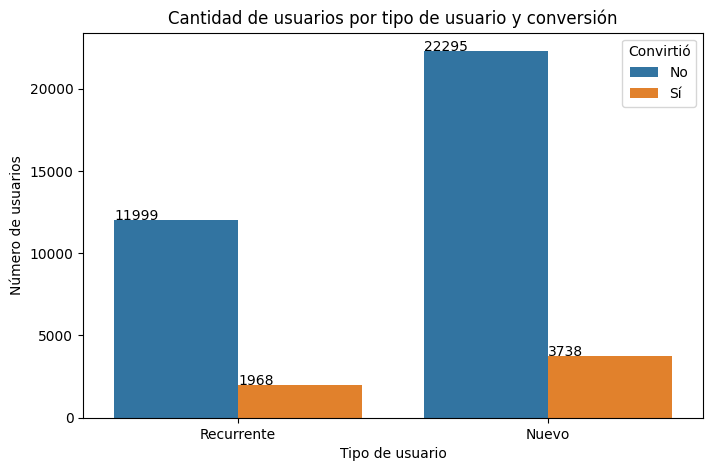

In [23]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='user_type', hue='converted')

# Agregar valores
for bar in ax.patches:           # Recorrer todas las barras del gráfico
    height = bar.get_height()    # Obtener altura de la barra (conteo de usuarios)
    ax.text(x=bar.get_x(),         # Establecer coordenada X del texto (inicio de la barra)
            y=height,              # Establecer coordenada Y del texto (parte superior de la barra)
            s=height)              # Valor númerico a mostrar
    
plt.title('Cantidad de usuarios por tipo de usuario y conversión')
plt.xlabel('Tipo de usuario')
plt.ylabel('Número de usuarios')
plt.legend(title='Convirtió', labels=['No', 'Sí'])
plt.show()

✍️ **Comentario**: 
En términos absolutos, los usuarios Nuevos generan más conversiones (3,738) que los Recurrentes (1,968). Esto se explica principalmente porque también son casi el doble en volumen total (26,033 vs 13,967), y no porque conviertan proporcionalmente mejor.

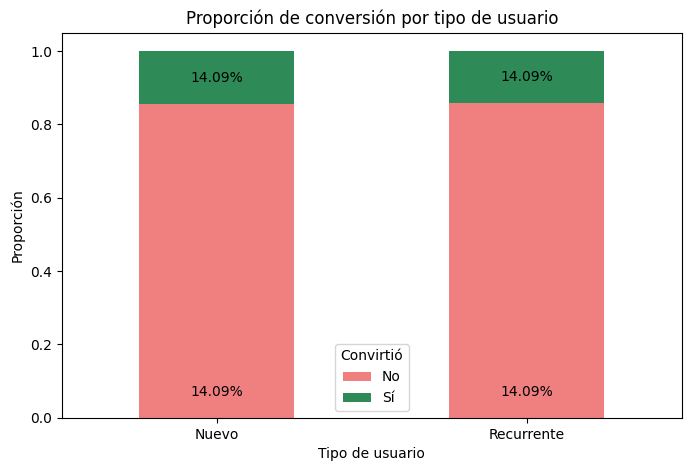

In [25]:
proporciones_tipo = pd.crosstab(df['user_type'], df['converted'], normalize='index')

ax = proporciones_tipo.plot(kind='bar', stacked=True, figsize=(8,5), color=['lightcoral', 'seagreen'])

# Agregar valores
for bar in ax.patches:           # Recorrer todas las barras del gráfico
    x_centro = bar.get_x() + bar.get_width() /2
    y_centro = bar.get_y() + height/ 2
    ax.text(x=x_centro,         # Establecer coordenada X del texto (inicio de la barra)
            y=y_centro,              # Establecer coordenada Y del texto (parte superior de la barra)
            s=f'{height:.2%}',              # Valor númerico a mostrar
            ha='center', 
            va='center')
    
plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')
plt.legend(title='Convirtió', labels=['No', 'Sí'])
plt.xticks(rotation=0)
plt.show()

height = bar.get_height()    # Obtener altura de la barra (conteo de usuarios)
   

✍️ **Comentario**: 
Al ver la proporción, las tasas de conversión son prácticamente idénticas entre ambos grupos: 14.36% para Nuevos y 14.09% para Recurrentes. Esto confirma lo encontrado con la prueba Z (p = 0.4644): el tipo de usuario no tiene una influencia estadísticamente significativa sobre la probabilidad de conversión — a diferencia de la fuente de tráfico o la página vista, ser nuevo o recurrente no parece ser un factor relevante para predecir si un usuario convertirá.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1: Los usuarios convertidos de la página B gastan en promedio $68.75, frente a $61.09 de la página A — una diferencia de $7.66 por usuario.
- Observacion 2: La prueba de Welch confirmó que esta diferencia es estadísticamente significativa (p = 3.63 × 10⁻²¹), por lo que no se debe al azar.
- **Interpretación:**
  La página B no solo convierte más usuarios, sino que además esos usuarios gastan más dinero, generando mayor valor económico por cliente para el negocio.

 
**Tasa de conversión:** 
- Observacion 1: La página B tiene una tasa de conversión de 15.96%, frente al 12.57% de la página A — casi 3.4 puntos porcentuales de diferencia.
- Observacion 2: La prueba Z de proporciones confirmó que esta diferencia es estadísticamente significativa (p = 3.76 × 10⁻²²).
- **Interpretación:**
- La página B convierte visitantes en clientes de forma consistentemente más efectiva que la página A, en volumen y no solo por azar muestral.

---

#### 📊 **Segmentación por fuente de tráfico**
- Observacion:
- Email (14.99%) y Ads (14.74%) tienen tasas de conversión relativas ligeramente más altas que Organic (13.79%) y Referral (13.88%), aunque Organic genera el mayor número absoluto de conversiones (2,480) por su alto volumen de tráfico. La prueba Chi-cuadrado mostró una asociación estadísticamente significativa, aunque modesta (p = 0.034).
- **Interpretación:**
- Los canales pagados y de email son proporcionalmente más eficientes por visitante, aunque el canal orgánico sigue siendo el mayor generador de volumen; la diferencia entre canales es real pero no muy pronunciada.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observacion:
- Las tasas de conversión son prácticamente idénticas entre usuarios Nuevos (14.36%) y Recurrentes (14.09%), y la prueba Z no encontró diferencia estadísticamente significativa (p = 0.4644).
- **Interpretación:**
- El tipo de usuario no es un factor relevante para predecir conversión en este experimento — probablemente porque "recurrente" solo indica una visita previa, no necesariamente lealtad o intención de compra.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la página B como versión definitiva del landing, ya que supera consistentemente a la página A tanto en tasa de conversión como en gasto promedio por cliente convertido, generando mayor valor económico general.
- Priorizar o reforzar la inversión en los canales de Email y Ads, dado que muestran una eficiencia de conversión relativa ligeramente superior, sin dejar de aprovechar el volumen que aporta el tráfico Organic; dado que el tipo de usuario no influye en la conversión, no es necesario diferenciar estrategias de landing entre usuarios nuevos y recurrentes.